<a href="https://www.kaggle.com/code/kaushikfreddyregalla/02-preprocessing-data-augmentation?scriptVersionId=325264838" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 02 — Preprocessing & Data Augmentation
Hand Gesture Recognition | Kaushik Reddy Ragalla

In [1]:
import os, random, sys, io, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
_stderr = sys.stderr; sys.stderr = io.StringIO()
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from collections import Counter
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
sys.stderr = _stderr

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.makedirs('figures', exist_ok=True)

# ── Find dataset root ────────────────────────────────────────────────────────
SEARCH_BASES = [
    '/kaggle/input/datasets/kaushikfreddyregalla/hand-gesture-recognition-algorithm-using-cnn',
    '/kaggle/input/datasets/kaushikfreddyregalla',
    '/kaggle/input/datasets',
    '/kaggle/input',
]
DATASET_ROOT = None
for base in SEARCH_BASES:
    b = Path(base)
    if not b.exists(): continue
    for p in b.rglob('leapGestRecog'):
        if not p.is_dir(): continue
        children = [c.name for c in p.iterdir() if c.is_dir()]
        if any(c in ['00','01','02','03','04'] for c in children):
            DATASET_ROOT = p; break
    if DATASET_ROOT: break

assert DATASET_ROOT is not None, 'Dataset not found!'
print(f'DATASET_ROOT = {DATASET_ROOT}')

IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
CLASS_NAMES = ['01_palm','02_l','03_fist','04_fist_moved','05_thumb',
               '06_index','07_ok','08_palm_moved','09_c','10_down']
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes: {CLASS_NAMES}')


E0000 00:00:1780870876.614018      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780870876.684669      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780870877.230626      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780870877.230677      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780870877.230680      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780870877.230683      23 computation_placer.cc:177] computation placer already registered. Please check linka

DATASET_ROOT = /kaggle/input/datasets/kaushikfreddyregalla/hand-gesture-recognition-algorithm-using-cnn/leapGestRecog
Classes: ['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']


In [2]:
# ── Collect all image paths and labels ───────────────────────────────────────
all_paths, all_labels = [], []

for subject_dir in sorted(DATASET_ROOT.iterdir()):
    if not subject_dir.is_dir(): continue
    for class_dir in sorted(subject_dir.iterdir()):
        if not class_dir.is_dir() or class_dir.name not in CLASS_NAMES: continue
        label = CLASS_NAMES.index(class_dir.name)
        for img_file in class_dir.glob('*.png'):
            all_paths.append(str(img_file))
            all_labels.append(label)

print(f'Found {len(all_paths)} images')
print(f'Label distribution: {Counter(all_labels)}')


Found 20000 images
Label distribution: Counter({0: 2000, 1: 2000, 2: 2000, 3: 2000, 4: 2000, 5: 2000, 6: 2000, 7: 2000, 8: 2000, 9: 2000})


In [3]:
# ── Load & preprocess images ─────────────────────────────────────────────────
# Grayscale, resize to 128x128, normalize to [0, 1]

def load_images(paths, labels, img_size=IMG_SIZE):
    X, y = [], []
    for path, label in zip(paths, labels):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img = cv2.resize(img, img_size)       # resize
        img = img.astype('float32') / 255.0   # normalize to [0, 1]
        X.append(img); y.append(label)
    X = np.array(X)[..., np.newaxis]  # shape: (N, 128, 128, 1)
    return X, np.array(y)

print('Loading images ... (this may take a minute)')
X, y = load_images(all_paths, all_labels)
print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'Pixel range: [{X.min():.2f}, {X.max():.2f}]')

Loading images ... (this may take a minute)
X shape: (20000, 128, 128, 1), y shape: (20000,)
Pixel range: [0.00, 1.00]


In [4]:
# ── Train / Validation / Test split: 70 / 15 / 15 ────────────────────────────
y_cat = to_categorical(y, num_classes=NUM_CLASSES)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_cat, test_size=0.30, stratify=y, random_state=SEED)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    stratify=np.argmax(y_temp, axis=1), random_state=SEED)

print(f'Train : {X_train.shape[0]}')
print(f'Val   : {X_val.shape[0]}')
print(f'Test  : {X_test.shape[0]}')

# Save arrays for use in later notebooks
np.save('X_train.npy', X_train); np.save('y_train.npy', y_train)
np.save('X_val.npy',   X_val);   np.save('y_val.npy',   y_val)
np.save('X_test.npy',  X_test);  np.save('y_test.npy',  y_test)
print('Arrays saved as .npy files')

Train : 14000
Val   : 3000
Test  : 3000
Arrays saved as .npy files


In [5]:
# ── Data Augmentation ────────────────────────────────────────────────────────
# Applied to training set only — validation/test use no augmentation

train_datagen = ImageDataGenerator(
    rotation_range=15,       # rotate ±15 degrees
    width_shift_range=0.1,   # shift horizontally up to 10%
    height_shift_range=0.1,  # shift vertically up to 10%
    zoom_range=0.1,          # zoom in/out up to 10%
    horizontal_flip=True,    # random left-right flip
    fill_mode='nearest'      # fill gaps with nearest pixel
)
val_datagen = ImageDataGenerator()  # no augmentation

train_gen = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen   = val_datagen.flow(X_val,   y_val,   batch_size=BATCH_SIZE, shuffle=False)

print('Data generators ready.')

Data generators ready.


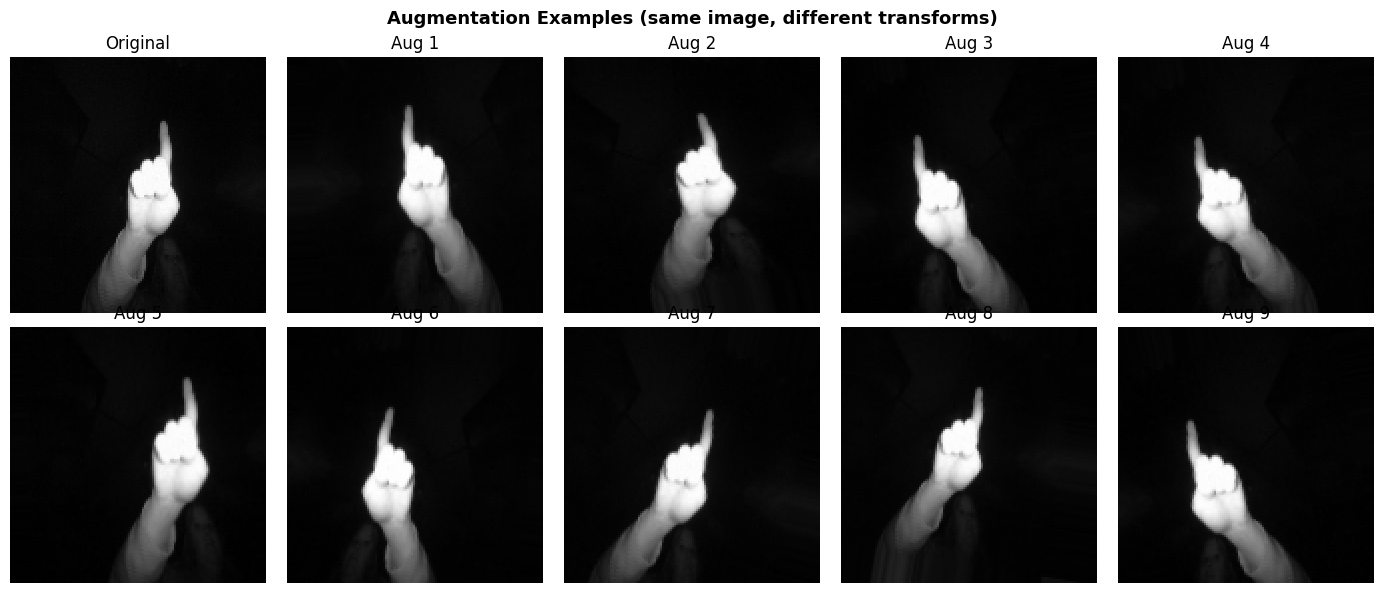

Preprocessing complete.


In [6]:
# ── Visualize augmentation examples ─────────────────────────────────────────
sample_img = X_train[0:1]  # one image, shape (1,128,128,1)
aug_gen = train_datagen.flow(sample_img, batch_size=1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Augmentation Examples (same image, different transforms)', fontsize=13, fontweight='bold')
axes[0, 0].imshow(sample_img[0, :, :, 0], cmap='gray')
axes[0, 0].set_title('Original'); axes[0, 0].axis('off')

for i, ax in enumerate(axes.flatten()[1:]):
    aug = next(aug_gen)[0, :, :, 0]
    ax.imshow(aug, cmap='gray')
    ax.set_title(f'Aug {i+1}'); ax.axis('off')

plt.tight_layout()
plt.savefig('figures/augmentation_examples.png', dpi=150)
plt.show()
print('Preprocessing complete.')